# Code for Figure 5 and corresponding supplementary figures

In [1]:
from data import PlateDataset

import torch
import numpy as np
import pandas as pd
from tqdm import trange, tqdm
import matplotlib.pyplot as plt
import torchvision.transforms as T 
import seaborn as sns
import umap


device = 'cuda:0'

## UMAP using pre-trained resnet features

Same UMAP as for Fig. 1 and 2. using cancer T1 and healthy, but not showing the cells from healthy volunteers here.

In [2]:
df = pd.read_csv('results/fig_2_umap_with_clusters.csv', index_col=0)

/tmp/ipykernel_2658653/544513941.py:1: DtypeWarning: Columns (13) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv('results/fig_2_umap_with_clusters.csv', index_col=0)


### Fig. 5a

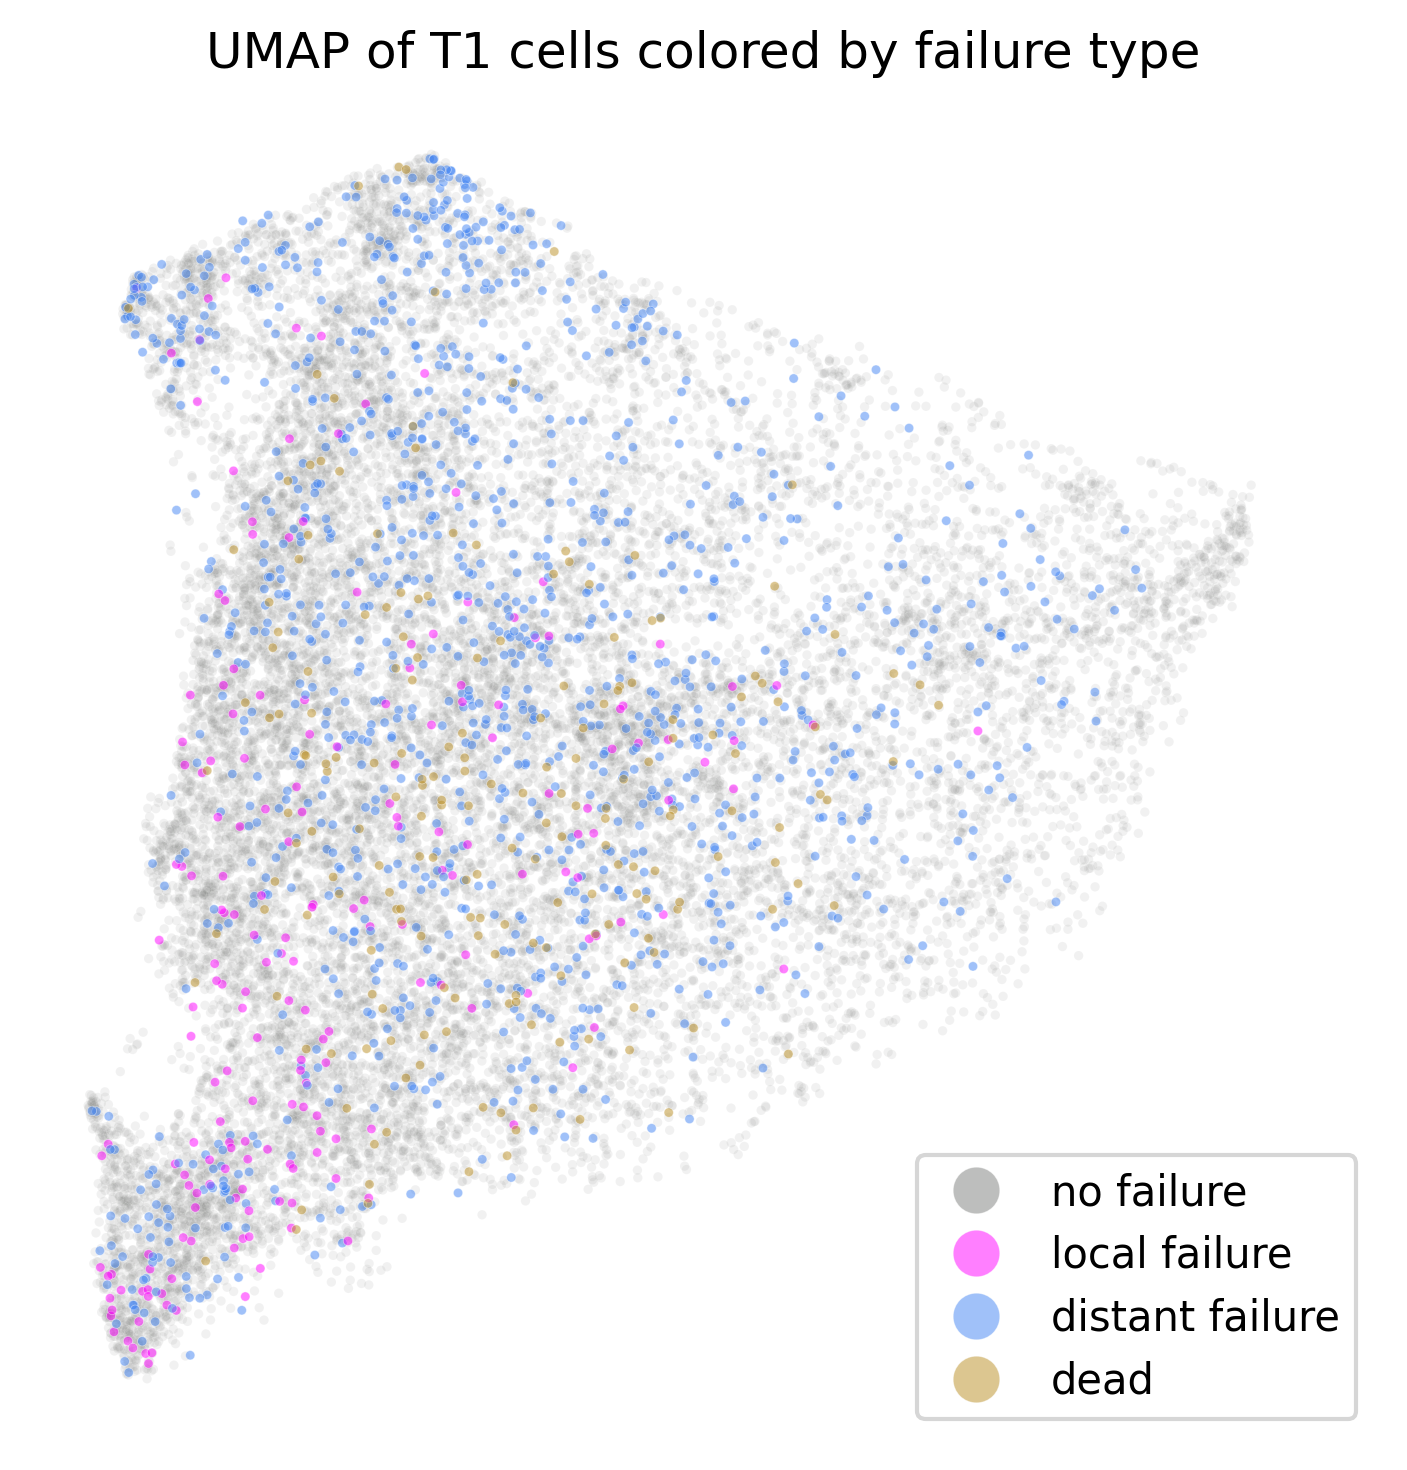

In [3]:
local_failure = ['P16', 'P34', 'P37', 'P40', 'P51', 'P66', 'P68', 'P72', 'P74', 'P92', 'P97', 'P125', 'P132', 'P136']
distant_failure = ['P11', 'P18', 'P20', 'P34', 'P49', 'P72', 'P87', 'P91', 'P97', 'P99', 'P103', 'P125', 'P151']
dead = ['P11', 'P34', 'P51', 'P66', 'P88', 'P91', 'P97']
df['outcome'] = 'no failure'
# overwrite with most severe
df.loc[df['patient'].isin(local_failure), 'outcome'] = 'local failure'
df.loc[df['patient'].isin(distant_failure), 'outcome'] = 'distant failure'
df.loc[df['patient'].isin(dead), 'outcome'] = 'dead'

fig, ax = plt.subplots(1, 1, figsize=(9, 5), dpi=300)
m = 'patient'
g = sns.scatterplot(data=df[(df['time'] == 1) & (df['outcome'] == 'no failure') & (df['diagnosis'] != 'healthy') 
                            & (df['plate'].astype(int) > 1) & (df['plate'].astype(int) < 15)], 
                    x='umap_x', y='umap_y', hue='outcome',
                    palette={'no failure' : '#7d7f7c', 'local failure' : '#FF00FF', 'distant failure' : '#4285f4', 'dead' : '#BA8E23'}, 
                    s=5, alpha=0.1, ax=ax, legend=False)
# skip patients without trajectories
g = sns.scatterplot(data=df[(df['time'] == 1) & ~df['patient'].isin(['P66', 'P37']) & (df['outcome'] != 'no failure') 
                            & (df['plate'].astype(int) > 1) & (df['plate'].astype(int) < 15)], 
                    x='umap_x', y='umap_y', hue='outcome',
                    palette={'no failure' : '#7d7f7c', 'local failure' : '#FF00FF', 'distant failure' : '#4285f4', 'dead' : '#BA8E23'}, 
                    s=5, alpha=0.5, ax=ax, hue_order=['no failure', 'local failure', 'distant failure', 'dead']) 
ax.set_title(f'UMAP of T1 cells colored by failure type')
ax.axis('square')
ax.axis('off')
sns.move_legend(g, 'best', title=None, markerscale=5)

fig.tight_layout()

### Fig. S5c

In [4]:
traj = pd.read_csv('results/1_16_t01_healthy_cancer_without_plate_by_cell_mil_architecture_relaxed_trajectory_classes.csv', index_col='patient')

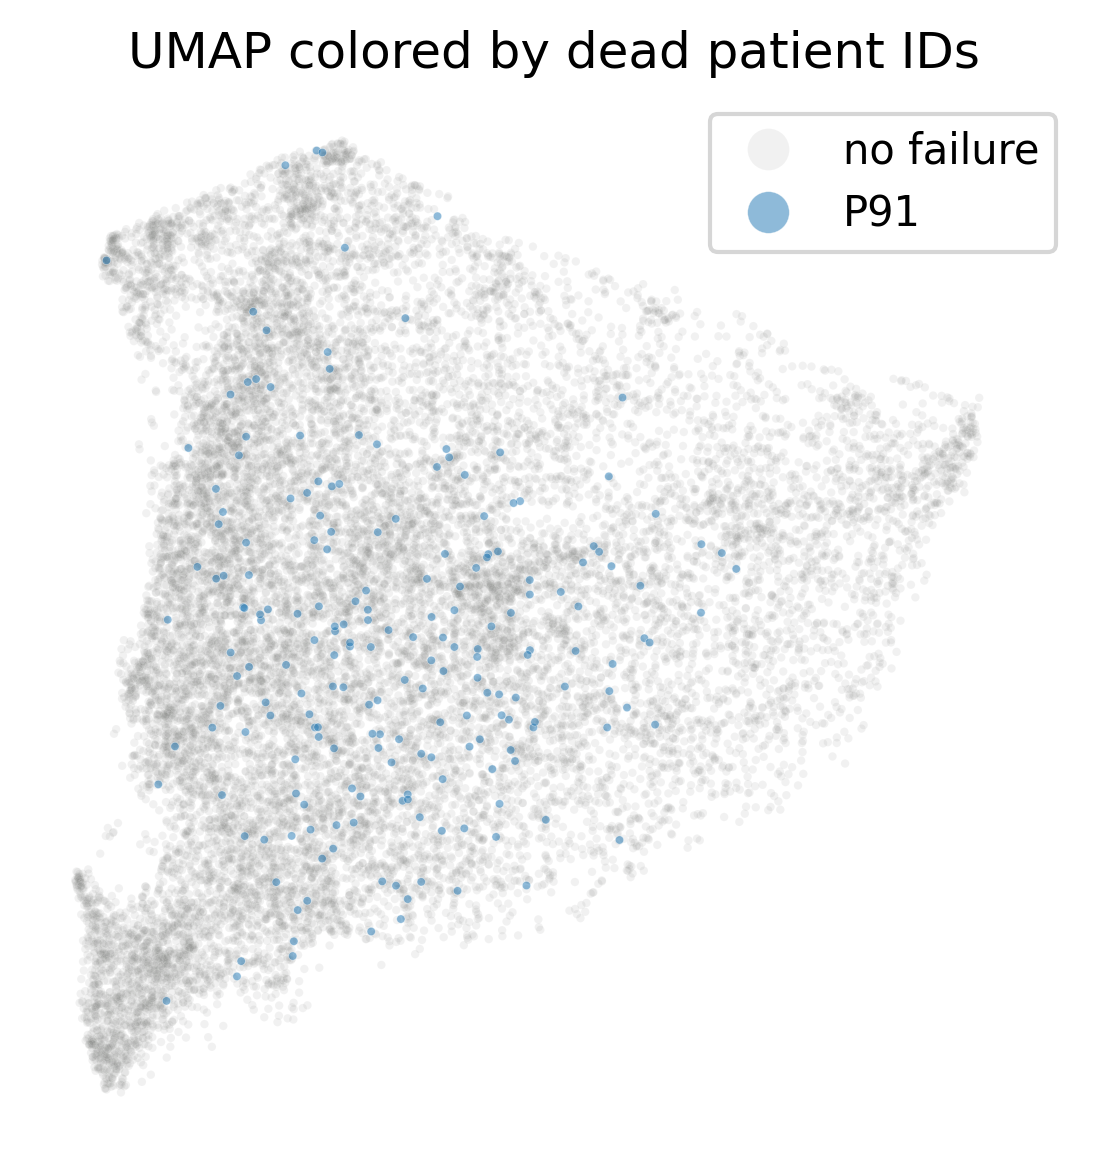

In [5]:
fig, ax = plt.subplots(1, 1, figsize=(4, 4), dpi=300)
m = 'patient'
g = sns.scatterplot(data=df[(df['time'] == 1) & (df['outcome'] == 'no failure') & (df['diagnosis'] != 'healthy') 
                            & (df['plate'].astype(int) > 1) & (df['plate'].astype(int) < 15)], 
                    x='umap_x', y='umap_y', hue='outcome',
                    palette={'no failure' : '#7d7f7c', 'local failure' : '#FF00FF', 'distant failure' : '#4285f4', 'dead' : '#BA8E23'}, 
                    s=4, alpha=0.1, ax=ax)

g = sns.scatterplot(data=df[(df['time'] == 1) & (df['outcome'] == 'dead') 
                            & (df['patient'] != 'P66') # P66 doesn't have trajectory 
                            & (df['plate'].astype(int) > 1) & (df['plate'].astype(int) < 15)], 
                    x='umap_x', y='umap_y', hue='patient',
                    s=4, alpha=0.5, ax=ax,) 
ax.set_title(f'UMAP colored by dead patient IDs')
ax.axis('square')
ax.axis('off')
sns.move_legend(g, 'best', title=None, markerscale=5)

fig.tight_layout()

In [6]:
traj[traj.index.isin(dead)]

,trajectory
patient,
P66,NaN
P91,up


### Fig. S5a

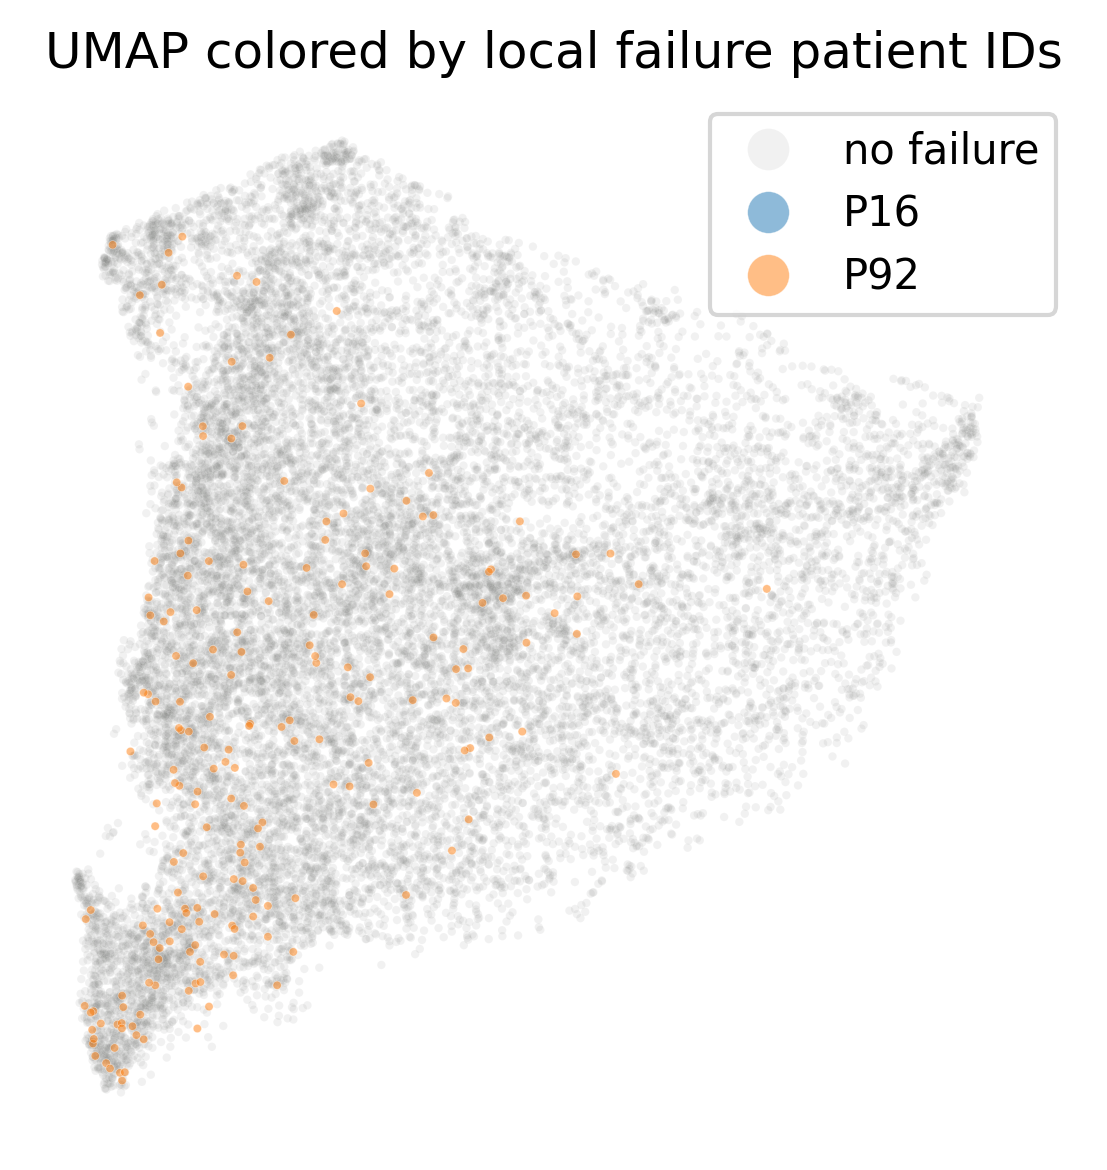

In [7]:
fig, ax = plt.subplots(1, 1, figsize=(4, 4), dpi=300)
m = 'patient'
g = sns.scatterplot(data=df[(df['time'] == 1) & (df['outcome'] == 'no failure') & (df['diagnosis'] != 'healthy') 
                            & (df['plate'].astype(int) > 1) & (df['plate'].astype(int) < 15)], 
                    x='umap_x', y='umap_y', hue='outcome',
                    palette={'no failure' : '#7d7f7c', 'local failure' : '#FF00FF', 'distant failure' : '#4285f4', 'dead' : '#BA8E23'}, 
                    s=4, alpha=0.1, ax=ax)

g = sns.scatterplot(data=df[(df['time'] == 1) & (df['outcome'] == 'local failure') 
                            & (df['patient'] != 'P37') # P37 doesn't have trajectory 
                            & (df['plate'].astype(int) > 1) & (df['plate'].astype(int) < 15)], 
                    x='umap_x', y='umap_y', hue='patient',
                    s=4, alpha=0.5, ax=ax,) 
ax.set_title(f'UMAP colored by local failure patient IDs')
ax.axis('square')
ax.axis('off')
sns.move_legend(g, 'upper right', title=None, markerscale=5)

fig.tight_layout()

In [8]:
traj[traj.index.isin(local_failure)]

,trajectory
patient,
P125,high
P16,low
P37,NaN
P66,NaN
P72,low
P92,low


### Fig. S5b

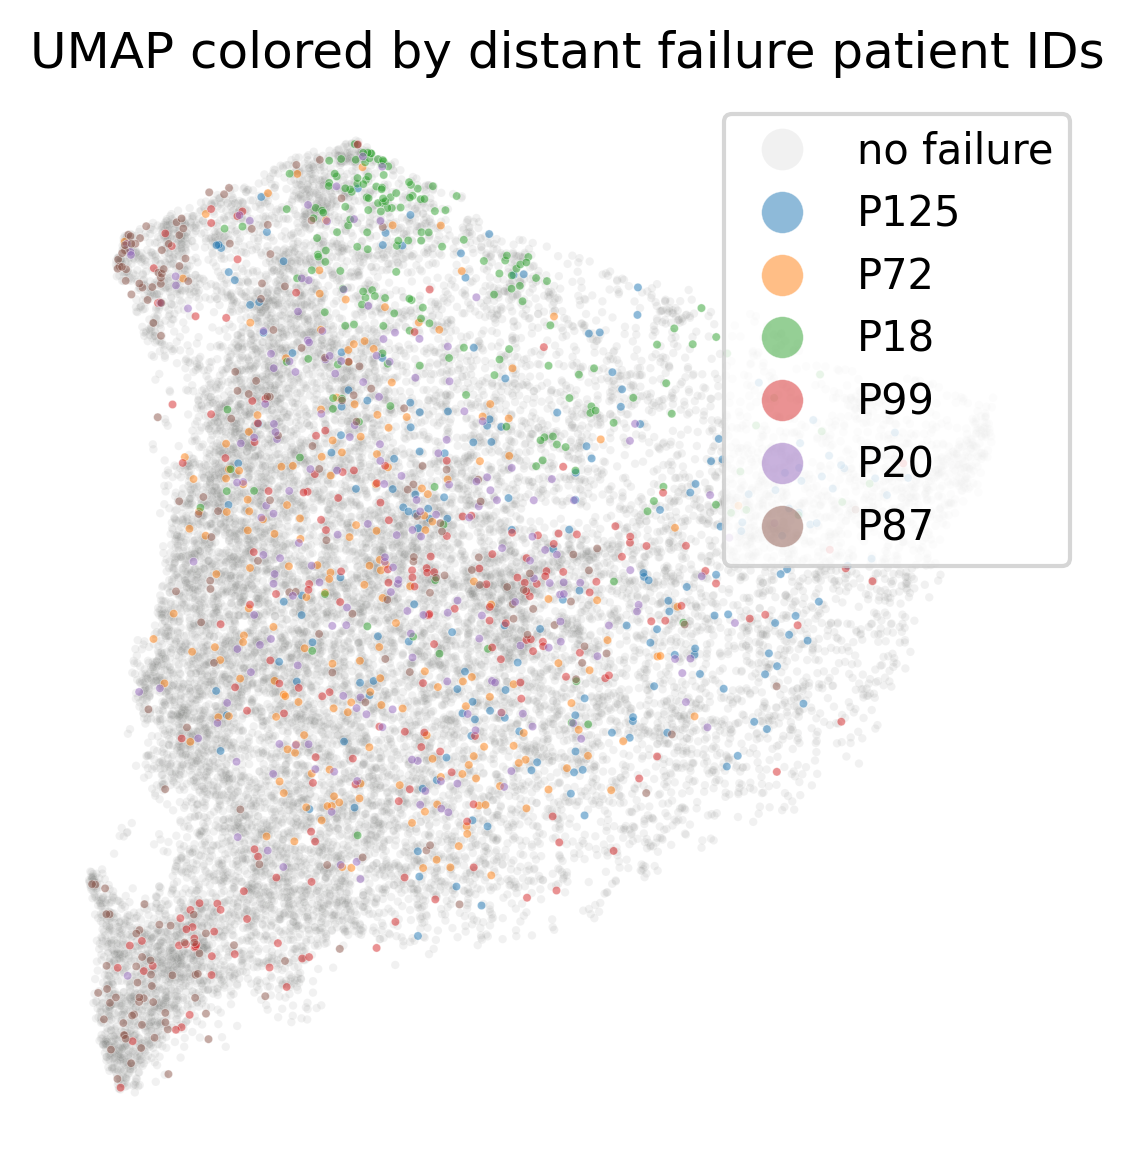

In [9]:
fig, ax = plt.subplots(1, 1, figsize=(4, 4), dpi=300)
m = 'patient'
g = sns.scatterplot(data=df[(df['time'] == 1) & (df['outcome'] == 'no failure') & (df['diagnosis'] != 'healthy') 
                            & (df['plate'].astype(int) > 1) & (df['plate'].astype(int) < 15)], 
                    x='umap_x', y='umap_y', hue='outcome',
                    palette={'no failure' : '#7d7f7c', 'local failure' : '#FF00FF', 'distant failure' : '#4285f4', 'dead' : '#BA8E23'}, 
                    s=4, alpha=0.1, ax=ax)

g = sns.scatterplot(data=df[(df['time'] == 1) & (df['outcome'] == 'distant failure') 
                            & (df['plate'].astype(int) > 1) & (df['plate'].astype(int) < 15)], 
                    x='umap_x', y='umap_y', hue='patient',
                    s=4, alpha=0.5, ax=ax,) 
ax.set_title(f'UMAP colored by distant failure patient IDs')
ax.axis('square')
ax.axis('off')
sns.move_legend(g, 'upper right', title=None, markerscale=5)

fig.tight_layout()

In [10]:
traj[traj.index.isin(distant_failure)]

,trajectory
patient,
P125,high
P18,low
P20,low
P72,low
P87,low
P91,up
P99,low


## List patients for cancer types and failure types

In [11]:
traj = pd.read_csv('results/1_16_t01_healthy_cancer_without_plate_by_cell_mil_architecture_relaxed_trajectory_classes.csv', index_col='patient')
groups = pd.read_csv('meta/patient_diagnosis_groups.csv')

local_failure = ['P16', 'P34', 'P37', 'P40', 'P51', 'P66', 'P68', 'P72', 'P74', 'P92', 'P97', 'P125', 'P132', 'P136']
distant_failure = ['P11', 'P18', 'P20', 'P34', 'P49', 'P72', 'P87', 'P91', 'P97', 'P99', 'P103', 'P125', 'P151']
dead = ['P11', 'P34', 'P51', 'P66', 'P88', 'P91', 'P97']

pat_info = groups.merge(traj, on='patient', how='left').set_index('patient')
pat_info['local'] = False
pat_info.loc[local_failure, 'local'] = True
pat_info['distant'] = False
pat_info.loc[distant_failure, 'distant'] = True
pat_info['death'] = False
pat_info.loc[dead, 'death'] = True
pat_info['any'] = pat_info[['local', 'distant', 'death']].any(axis='columns')
pat_info


,group,trajectory,local,distant,death,any
patient,,,,,,
P11,Sarcoma-Rhabdomyosarcoma,NaN,False,True,True,True
P12,H&N cancer,NaN,False,False,False,False
P13,Lymphoma,low,False,False,False,False
P14,H&N cancer,low,False,False,False,False
P15,CNS-Glioma,low,False,False,False,False
...,...,...,...,...,...,...
H46,healthy,NaN,False,False,False,False
H47,healthy,NaN,False,False,False,False
H48,healthy,NaN,False,False,False,False


### Fig. 5c

In [12]:
ps = pat_info[pat_info['group'] == 'H&N cancer'].reset_index().groupby('trajectory')['patient'].unique()
print('low:', ', '.join(ps.loc['low']))
print('up:', ', '.join(ps.loc['up']))
print('high:', ', '.join(ps.loc['high']))

ps = pat_info[(pat_info['group'] == 'H&N cancer') & (pat_info['any'])].reset_index()['patient'].unique()
pat_info.loc[ps]

low: P14, P18, P55, P63, P72, P107, P110, P145, P148, P149
up: P41, P56, P67, P77, P78, P79, P94, P98, P100, P114, P120, P130, P135, P142
high: P125, P129, P154, P166


,group,trajectory,local,distant,death,any
patient,,,,,,
P18,H&N cancer,low,False,True,False,True
P72,H&N cancer,low,True,True,False,True
P125,H&N cancer,high,True,True,False,True


In [13]:
ps = pat_info[pat_info['group'] == 'CNS-Meningioma'].reset_index().groupby('trajectory')['patient'].unique()
print('low:', ', '.join(ps.loc['low']))
print('up:', ', '.join(ps.loc['up']))
print('high:', ', '.join(ps.loc['high']))

ps = pat_info[(pat_info['group'] == 'CNS-Meningioma') & (pat_info['any'])].reset_index()['patient'].unique()
pat_info.loc[ps]

low: P38, P48, P59, P105, P162
up: P33, P62, P70, P83, P128, P133
high: P42, P119, P134, P157


,group,trajectory,local,distant,death,any
patient,,,,,,
P37,CNS-Meningioma,NaN,True,False,False,True


In [14]:
ps = pat_info[pat_info['group'] == 'Chordoma/Chondrosarcoma'].reset_index().groupby('trajectory')['patient'].unique()
print('low:', ', '.join(ps.loc['low']))
print('up:', ', '.join(ps.loc['up']))
print('high:', ', '.join(ps.loc['high']))

ps = pat_info[(pat_info['group'] == 'Chordoma/Chondrosarcoma') & (pat_info['any'])].reset_index()['patient'].unique()
pat_info.loc[ps]

low: P21, P25, P43, P69, P76, P92, P99, P143
up: P23, P90, P112, P118, P138
high: P126, P131, P152, P165


,group,trajectory,local,distant,death,any
patient,,,,,,
P92,Chordoma/Chondrosarcoma,low,True,False,False,True
P99,Chordoma/Chondrosarcoma,low,False,True,False,True


### Fig. 5b

In [15]:
pat_info['trajectory'].value_counts()

trajectory
low     44
up      39
high    14
Name: count, dtype: int64

In [16]:
pat_info.groupby('trajectory')[['local', 'distant', 'death', 'any']].sum()

,local,distant,death,any
trajectory,,,,
high,1,1,0,1
low,3,5,0,7
up,0,1,1,1


**The below code needs to be run locally -- it requires files that are not on the server for privacy reasons.**

In [17]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from matplotlib.colors import LinearSegmentedColormap
import matplotlib.patches as mpatches

In [18]:
meta = pd.read_excel('sensitive/CRF_ChroMark.xlsx', sheet_name='CRF', header=None, skiprows=12)
meta['patient'] = 'P' + meta[0].str[-3:].astype(int).astype(str)
meta = meta.set_index('patient').rename(columns={36:'end of PT', 30:'T5 days after end of PT',
                                                 27:'T4 days after end of PT'})

/ewsc/hschluet/conda_stuff/anaconda3/envs/new-img-39/lib/python3.9/site-packages/openpyxl/worksheet/_reader.py:329: UserWarning: Data Validation extension is not supported and will be removed
  warn(msg)


In [19]:
meta[15].value_counts()

15
Subtotal resection    51
Complete resection    45
Biopsy only           39
No Biopsy             10
Name: count, dtype: int64

In [20]:
meta[18].str.strip().str.replace('//', '').str.replace(',', '').str.replace('  ', ' ').str.replace('tumore', 'tumor').value_counts()

18
Gross tumor volume                                59
Tumor bed                                         36
Gross tumor volume Tumor bed                      19
Gross tumor volume Lymph nodes                    14
Tumor bed Lymph nodes                              5
Craniospinal axis                                  3
Tumor bed Craniospinal axis                        2
Gross tumor volume Lymph nodes Metastases          2
Lymph nodes                                        1
Gross tumor volume Tumor bed Lymph nodes           1
Metastases Craniospinal axis                       1
Gross tumor volume Craniospinal axis               1
Metastases                                         1
Gross tumor volume Metastases                      1
Craniospinalaxis                                   1
Gross tumor volume Tumor bed Craniospinal axis     1
Name: count, dtype: int64

In [21]:
meta[41].value_counts()

41
No               117
Chemotherapy      28
Cheomotherapy      1
Immunotherapy      1
Name: count, dtype: int64

In [ ]:
traj = pd.read_csv('results/1_16_t01_healthy_cancer_without_plate_by_cell_mil_architecture_relaxed_trajectory_classes.csv')

traj = traj.merge(meta[[3, 4, 7, 15, 18, 34, 41, 35, 'end of PT']], on='patient').rename(columns={
    3 : 'age', 4 : 'gender',
    7 : 'group', 15 : 'resection status', 18 : 'PT target', 34 : 'size at start', 41 : 'concomitant treatment',
    35 : 'first irradiated volume'})
traj['PT target'] = traj['PT target'].str.strip().str.replace('//', '').str.replace(',', '').str.replace('  ', ' ').str.replace('tumore', 'tumor')
traj

## Trajectory and metadata correlations for Head & Neck cancer

In [23]:
hn_traj = traj[traj['group'] == 'H&N cancer']

### Fig. S5j

In [24]:
print('total', len(hn_traj))
print('missing', len(hn_traj[hn_traj['size at start'].str.contains('Barbara') | hn_traj['size at start'].str.contains('NaN') | 
                             hn_traj['size at start'].isna() | hn_traj['size at start'].str.contains('Alessia')]))

total 37
missing 17


20


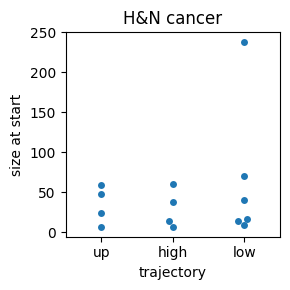

In [25]:
hn_size = hn_traj[~(hn_traj['size at start'].str.contains('Barbara') | hn_traj['size at start'].str.contains('NaN') | 
          hn_traj['size at start'].isna() | hn_traj['size at start'].str.contains('Alessia'))]
print(len(hn_size))

fig, ax = plt.subplots(1, 1, figsize=(3, 3))
sns.swarmplot(hn_size, x='trajectory', y='size at start', ax=ax)
ax.set_title('H&N cancer')
fig.tight_layout()

### Fig. 5e

37


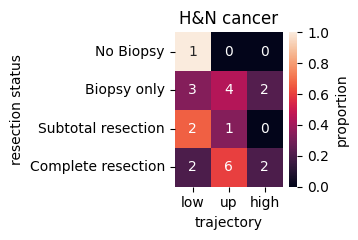

In [26]:
hn_res = hn_traj[~(hn_traj['resection status'].str.contains('NaN') | hn_traj['resection status'].isna())]
print(len(hn_res))

fig, ax = plt.subplots(1, 1, figsize=(3.5, 2.5))
mat = hn_res.groupby('trajectory')['resection status'].value_counts().reset_index().pivot(index='resection status',
                                                                                                  columns=['trajectory'], values='count').fillna(0).astype(int).loc[
                                                                                                      ['No Biopsy', 'Biopsy only', 'Subtotal resection', 'Complete resection'],
                                                                                                  ['low', 'up', 'high']]
sns.heatmap(mat.div(mat.sum(axis=1), axis=0), annot=mat, ax=ax, cbar_kws={'label': 'proportion'}, vmin=0, vmax=1)
ax.set_title('H&N cancer')
fig.tight_layout()

### Fig. S5l

37


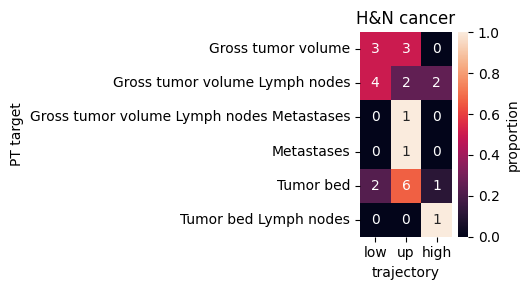

In [27]:
hn_target = hn_traj[~(hn_traj['PT target'].str.contains('NaN') | hn_traj['PT target'].isna())]
print(len(hn_target))

fig, ax = plt.subplots(1, 1, figsize=(5, 3))

mat = hn_target.groupby('trajectory')['PT target'].value_counts().reset_index().pivot(index='PT target',
                                                                                                  columns=['trajectory'], values='count').fillna(0).astype(int)[
                                                                                                  ['low', 'up', 'high']] 
sns.heatmap(mat.div(mat.sum(axis=1), axis=0), annot=mat, ax=ax, cbar_kws={'label': 'proportion'}, vmin=0, vmax=1)
ax.set_title('H&N cancer')
fig.tight_layout()

### Fig. 5g

37


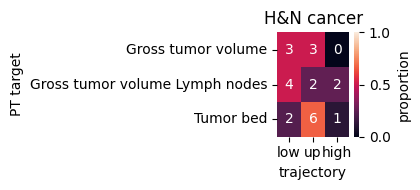

In [28]:
hn_target = hn_traj[~(hn_traj['PT target'].str.contains('NaN') | hn_traj['PT target'].isna())]
print(len(hn_target))

fig, ax = plt.subplots(1, 1, figsize=(4, 2))

mat = hn_target.groupby('trajectory')['PT target'].value_counts().reset_index().pivot(index='PT target',
                                                                                                  columns=['trajectory'], values='count').fillna(0).astype(int)[
                                                                                                  ['low', 'up', 'high']].iloc[[0, 1, 4]]
sns.heatmap(mat.div(mat.sum(axis=1), axis=0), annot=mat, ax=ax, cbar_kws={'label': 'proportion'}, vmin=0, vmax=1)
ax.set_title('H&N cancer')
fig.tight_layout()

### Fig. S5k

26


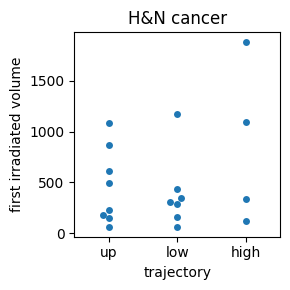

In [29]:
hn_pt_size = hn_traj[~hn_traj['first irradiated volume'].isna()]
print(len(hn_pt_size))

fig, ax = plt.subplots(1, 1, figsize=(3, 3))
sns.swarmplot(hn_pt_size, x='trajectory', y='first irradiated volume', ax=ax)
ax.set_title('H&N cancer')
fig.tight_layout()

### Fig. 5f

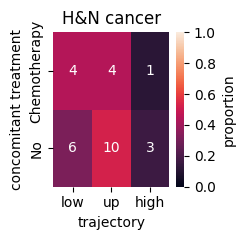

In [30]:
fig, ax = plt.subplots(1, 1, figsize=(2.5, 2.5))
mat = hn_traj.groupby('trajectory')['concomitant treatment'].value_counts().reset_index().pivot(index='concomitant treatment',
                                                                                                  columns=['trajectory'], values='count').fillna(0).astype(int)[
                                                                                                  ['low', 'up', 'high']]
sns.heatmap(mat.div(mat.sum(axis=1), axis=0), annot=mat, ax=ax, cbar_kws={'label': 'proportion'}, vmin=0, vmax=1)
ax.set_title('H&N cancer')
fig.tight_layout()

### Fig. S5e

122


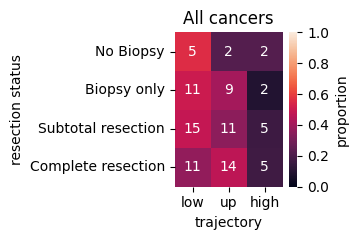

In [31]:
res_all = traj[~(traj['resection status'].str.contains('NaN') | traj['resection status'].isna())]
print(len(res_all))

fig, ax = plt.subplots(1, 1, figsize=(3.5, 2.5))
mat = res_all.groupby('trajectory')['resection status'].value_counts().reset_index().pivot(index='resection status',
                                                                                                  columns=['trajectory'], values='count').fillna(0).astype(int).loc[
                                                                                                      ['No Biopsy', 'Biopsy only', 'Subtotal resection', 'Complete resection'],
                                                                                                  ['low', 'up', 'high']]
sns.heatmap(mat.div(mat.sum(axis=1), axis=0), annot=mat, ax=ax, cbar_kws={'label': 'proportion'}, vmin=0, vmax=1)
ax.set_title('All cancers')
fig.tight_layout()

### Fig. S5f

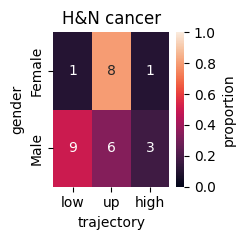

In [32]:
fig, ax = plt.subplots(1, 1, figsize=(2.5, 2.5))
mat = hn_traj.groupby('trajectory')['gender'].value_counts().reset_index().pivot(
    index='gender', columns=['trajectory'], values='count').fillna(0).astype(int)[['low', 'up', 'high']]
sns.heatmap(mat.div(mat.sum(axis=1), axis=0), annot=mat, ax=ax, cbar_kws={'label': 'proportion'}, vmin=0, vmax=1)
ax.set_title('H&N cancer')
fig.tight_layout()

### Fig. S5g

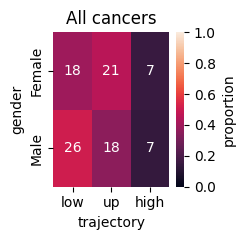

In [33]:
fig, ax = plt.subplots(1, 1, figsize=(2.5, 2.5))
mat = traj.groupby('trajectory')['gender'].value_counts().reset_index().pivot(
    index='gender', columns=['trajectory'], values='count').fillna(0).astype(int)[['low', 'up', 'high']]
sns.heatmap(mat.div(mat.sum(axis=1), axis=0), annot=mat, ax=ax, cbar_kws={'label': 'proportion'}, vmin=0, vmax=1)
ax.set_title('All cancers')
fig.tight_layout()

### Fig. S5h

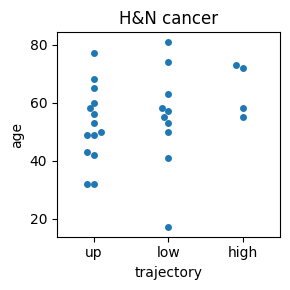

In [34]:
fig, ax = plt.subplots(1, 1, figsize=(3, 3))
sns.swarmplot(hn_traj, x='trajectory', y='age', ax=ax)
ax.set_title('H&N cancer')
fig.tight_layout()

### Fig. S5i

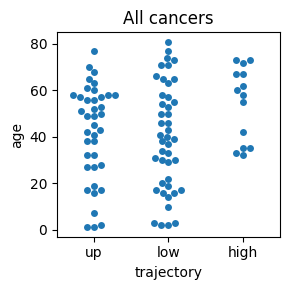

In [35]:
fig, ax = plt.subplots(1, 1, figsize=(3, 3))
sns.swarmplot(traj, x='trajectory', y='age', ax=ax)
ax.set_title('All cancers')
fig.tight_layout()

## Failure over time

In [36]:
out = pd.read_excel('sensitive/prelim_outcomes.xlsx', sheet_name='Sheet1')
out['patient'] = 'P' + out['Patient ID'].str[-3:].astype(int).astype(str)

In [37]:
meta = meta.rename(columns={36:'end of PT', 30:'T5 days after end of PT', 27:'T4 days after end of PT'})
meta['T3 days after end of PT'] = 0
meta['T2 days after end of PT'] = -21  # placeholder as I don't have actual dates
meta['T1 days after end of PT'] = -42  # placeholder as I don't have actual dates

meta['T1'] = meta['end of PT'] + pd.to_timedelta(meta['T1 days after end of PT'], 'days')
meta['T2'] = meta['end of PT'] + pd.to_timedelta(meta['T2 days after end of PT'], 'days')
meta['T3'] = meta['end of PT'] + pd.to_timedelta(meta['T3 days after end of PT'], 'days')
meta['T4'] = meta['end of PT'] + pd.to_timedelta(meta['T4 days after end of PT'].replace({'drop out':np.nan}), 'days')
meta['T5'] = meta['end of PT'] + pd.to_timedelta(meta['T5 days after end of PT'].replace({'drop out':np.nan, 'n/a d':np.nan}), 'days')


patient_dates = meta[['T1', 'T2', 'T3', 'T4', 'T5']]
patient_dates = patient_dates.merge(out[['Date of last clinical control', 'Date of last imaging', 'Local failure', 'Date of local failure', 'Distant failure', 'Date of first distant failure', 'Date of death', 'patient']], on='patient')
patient_dates[['Date of last clinical control', 'Date of last imaging']] = patient_dates[['Date of last clinical control', 'Date of last imaging']].replace({'no clinical or radiological follow-up available' : '', 'not available' : ''}) 
patient_dates['Date of last clinical control'] = pd.to_datetime(patient_dates['Date of last clinical control'])
patient_dates['Date of last imaging'] = pd.to_datetime(patient_dates['Date of last imaging'])
patient_dates['first failure date'] =  patient_dates[['Date of local failure', 'Date of first distant failure', 'Date of death']].min(axis=1)
patient_dates['last follow-up date'] = patient_dates[['Date of last clinical control', 'Date of last imaging', 'Date of death']].max(axis=1)
patient_dates['days to first failure'] = (patient_dates['first failure date'] - patient_dates['T3'])
patient_dates['days to last follow-up'] = (patient_dates['last follow-up date'] - patient_dates['T3']).dt.days
patient_dates = patient_dates.merge(traj, on='patient')
patient_dates['days to first failure'] = patient_dates['days to first failure'].dt.days.fillna(np.inf)

/tmp/ipykernel_2658653/3029480934.py:9: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  meta['T4'] = meta['end of PT'] + pd.to_timedelta(meta['T4 days after end of PT'].replace({'drop out':np.nan}), 'days')
/tmp/ipykernel_2658653/3029480934.py:10: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  meta['T5'] = meta['end of PT'] + pd.to_timedelta(meta['T5 days after end of PT'].replace({'drop out':np.nan, 'n/a d':np.nan}), 'days')


In [38]:
patient_dates.groupby('trajectory')['days to last follow-up'].max()

trajectory
high     756.0
low     1044.0
up      1043.0
Name: days to last follow-up, dtype: float64

### Fig. 5d

In [39]:
from scipy import stats

low_right = patient_dates[(patient_dates['trajectory'] == 'low') & (patient_dates['days to first failure'] == np.inf)]['days to last follow-up'].dropna().values
low_failures = stats.CensoredData(uncensored=patient_dates[(patient_dates['trajectory'] == 'low') & 
                                                           (patient_dates['days to first failure'] != np.inf)]['days to first failure'].dropna().values,
                                  right=low_right)
print(low_failures)

up_right = patient_dates[(patient_dates['trajectory'] == 'up') & (patient_dates['days to first failure'] == np.inf)]['days to last follow-up'].dropna().values
up_failures = stats.CensoredData(uncensored=patient_dates[(patient_dates['trajectory'] == 'up') & 
                                                           (patient_dates['days to first failure'] != np.inf)]['days to first failure'].dropna().values,
                                  right=up_right)
print(up_failures)
high_right = patient_dates[(patient_dates['trajectory'] == 'high') & (patient_dates['days to first failure'] == np.inf)]['days to last follow-up'].dropna().values
high_failures = stats.CensoredData(uncensored=patient_dates[(patient_dates['trajectory'] == 'high') & 
                                                           (patient_dates['days to first failure'] != np.inf)]['days to first failure'].dropna().values,
                                  right=high_right)
print(high_failures)


CensoredData(41 values: 7 not censored, 34 right-censored)
CensoredData(39 values: 1 not censored, 38 right-censored)
CensoredData(14 values: 1 not censored, 13 right-censored)


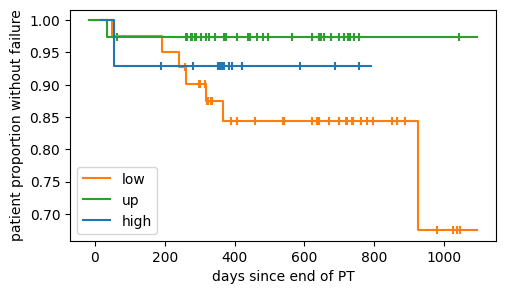

In [40]:
colors = {'up' : '#2ca02c', 'low' : '#ff7f0e', 'high' : '#1f77b4'}

fig, ax = plt.subplots(figsize=(5.5, 3))
ecdf_low = stats.ecdf(low_failures)
ecdf_low.sf.plot(ax, label='low', color=colors['low'])
ax.scatter(low_right, ecdf_low.sf.evaluate(low_right), marker='|', color=colors['low'])
ecdf_up = stats.ecdf(up_failures)
ecdf_up.sf.plot(ax, label='up', color=colors['up'])
ax.scatter(up_right, ecdf_up.sf.evaluate(up_right), marker='|', color=colors['up'])
ecdf_high = stats.ecdf(high_failures)
ecdf_high.sf.plot(ax, label='high', color=colors['high'])
ax.scatter(high_right, ecdf_high.sf.evaluate(high_right), marker='|', color=colors['high'])
ax.set_xlabel('days since end of PT')
ax.set_ylabel('patient proportion without failure')
plt.legend()
plt.show()

In [41]:
print('p-value for log-rank test with alternative low worse than high: {0:0.5f}'.format(
    stats.logrank(x=low_failures, y=high_failures, alternative='greater').pvalue))
print('p-value for log-rank test with alternative up worse than high: {0:0.5f}'.format(
    stats.logrank(x=up_failures, y=high_failures, alternative='greater').pvalue))
print('p-value for log-rank test with alternative low worse than up: {0:0.5f}'.format(
    stats.logrank(x=low_failures, y=up_failures, alternative='greater').pvalue))

p-value for log-rank test with alternative low worse than high: 0.26929
p-value for log-rank test with alternative up worse than high: 0.77220
p-value for log-rank test with alternative low worse than up: 0.03070


### Fig. S5d

CensoredData(41 values: 5 not censored, 36 right-censored)
CensoredData(36 values: 1 not censored, 35 right-censored)
CensoredData(37 values: 5 not censored, 32 right-censored)


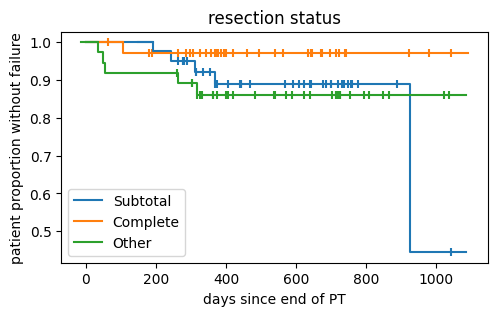

In [42]:
col = 'resection status'
options = ['Subtotal resection']
right1 = patient_dates[(patient_dates[col].isin(options)) & (patient_dates['days to first failure'] == np.inf)]['days to last follow-up'].dropna().values
failures1 = stats.CensoredData(uncensored=patient_dates[(patient_dates[col].isin(options)) & 
                                                           (patient_dates['days to first failure'] != np.inf)]['days to first failure'].dropna().values,
                                  right=right1)
print(failures1)

options = ['Complete resection']
right2 = patient_dates[(patient_dates[col].isin(options)) & (patient_dates['days to first failure'] == np.inf)]['days to last follow-up'].dropna().values
failures2 = stats.CensoredData(uncensored=patient_dates[(patient_dates[col].isin(options)) & 
                                                           (patient_dates['days to first failure'] != np.inf)]['days to first failure'].dropna().values,
                                  right=right2)
print(failures2)

options = ['Biopsy only', 'No Biopsy']
right3 = patient_dates[(patient_dates[col].isin(options)) & (patient_dates['days to first failure'] == np.inf)]['days to last follow-up'].dropna().values
failures3 = stats.CensoredData(uncensored=patient_dates[(patient_dates[col].isin(options)) & 
                                                           (patient_dates['days to first failure'] != np.inf)]['days to first failure'].dropna().values,
                                  right=right3)
print(failures3)

fig, ax = plt.subplots(figsize=(5.5, 3))
ecdf_1= stats.ecdf(failures1)
ecdf_1.sf.plot(ax, label='Subtotal', color=colors['high'])
ax.scatter(right1, ecdf_1.sf.evaluate(right1), marker='|', color=colors['high'])
ecdf_2= stats.ecdf(failures2)
ecdf_2.sf.plot(ax, label='Complete', color=colors['low'])
ax.scatter(right2, ecdf_2.sf.evaluate(right2), marker='|', color=colors['low'])
ecdf_3= stats.ecdf(failures3)
ecdf_3.sf.plot(ax, label='Other', color=colors['up'])
ax.scatter(right3, ecdf_3.sf.evaluate(right3), marker='|', color=colors['up'])
# extend each survival curve back to x=0 at y=1 (match Fig. 5d style)
for _opts, _seg_color in [(['Subtotal resection'], colors['high']), (['Complete resection'], colors['low']), (['Biopsy only', 'No Biopsy'], colors['up'])]:
    _first_failure = patient_dates[patient_dates[col].isin(_opts)]['days to first failure'].min()
    ax.plot([0, _first_failure], [1, 1], color=_seg_color)
ax.set_xlabel('days since end of PT')
ax.set_ylabel('patient proportion without failure')
ax.set_title(col)
plt.legend()
plt.show()

In [43]:
print('p-value for log-rank test with alternative subtotal worse than complete: {0:0.5f}'.format(
    stats.logrank(x=failures1, y=failures2, alternative='greater').pvalue))
print('p-value for log-rank test with alternative other worse than complete: {0:0.5f}'.format(
    stats.logrank(x=failures1, y=failures3, alternative='greater').pvalue))

p-value for log-rank test with alternative subtotal worse than complete: 0.07300
p-value for log-rank test with alternative other worse than complete: 0.57260


## Toxicity

In [44]:
res = pd.read_csv('results/1_16_t01_healthy_cancer_without_plate_by_cell_mil_architecture_relaxed_scores.csv')
res['score'] = res['score'].clip(upper=1)  # cap similarity-to-healthy at 1; >1 arises from plate noise / small held-out healthy sample
res = res[(res['plate'] > 1) & (res['plate'] <= 14)]
res = res.merge(meta[[3, 4, 7, 15, 18, 34, 41, 35, 'end of PT']], on='patient').rename(columns={
    3 : 'age', 4 : 'gender',
    7 : 'group', 15 : 'resection status', 18 : 'PT target', 34 : 'size at start', 41 : 'concomitant treatment',
    35 : 'first irradiated volume'})
t3_scores = res[res['time'] == 3][['patient', 'score', 'group']].dropna()
tox = pd.read_excel('sensitive/tox_data.xlsx', sheet_name='CRF', header=0, skiprows=[1])
tox['patient'] = 'P' + tox['Study Specific ID'].str[-3:].astype(int).astype(str)
df = t3_scores.merge(tox, on='patient')

### Fig. S5m

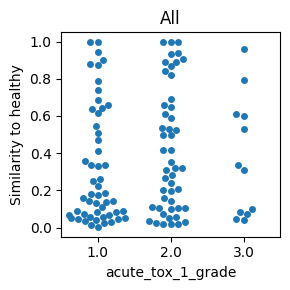

In [45]:
fig, ax = plt.subplots(1, 1, figsize=(3, 3))
sns.swarmplot(df, x='acute_tox_1_grade', y='score', ax=ax)
ax.set_title('All')
ax.set_ylabel('Similarity to healthy')
fig.tight_layout()

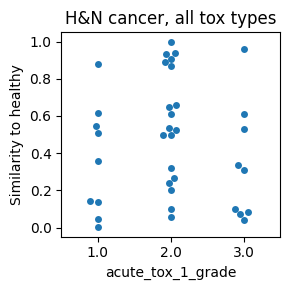

In [46]:
fig, ax = plt.subplots(1, 1, figsize=(3, 3))
sns.swarmplot(df[df['group'] == 'H&N cancer'], x='acute_tox_1_grade', y='score', ax=ax)
ax.set_title('H&N cancer, all tox types')
ax.set_ylabel('Similarity to healthy')
fig.tight_layout()

### Fig. S5n

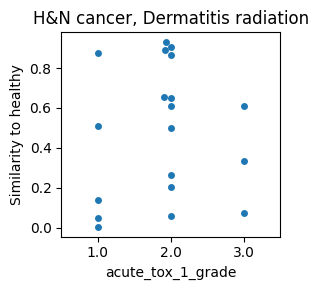

In [47]:
fig, ax = plt.subplots(1, 1, figsize=(3, 3))
sns.swarmplot(df[(df['group'] == 'H&N cancer') & (df['acute_tox_1_type'] == 'Dermatitis radiation')], x='acute_tox_1_grade', y='score', ax=ax)
ax.set_title('H&N cancer, Dermatitis radiation')
ax.set_ylabel('Similarity to healthy')
fig.tight_layout()

### Fig. S5o

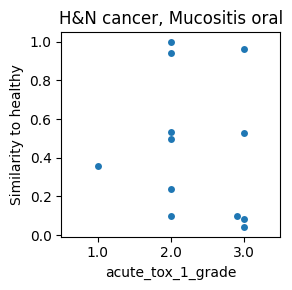

In [48]:
fig, ax = plt.subplots(1, 1, figsize=(3, 3))
sns.swarmplot(df[(df['group'] == 'H&N cancer') & (df['acute_tox_1_type'] == 'Mucositis oral')], x='acute_tox_1_grade', y='score', ax=ax)
ax.set_title('H&N cancer, Mucositis oral')
ax.set_ylabel('Similarity to healthy')
fig.tight_layout()

## Threshold robustness for trajectory classes

In [49]:
colors = {'up' : '#2ca02c', 'low' : '#ff7f0e', 'high' : '#1f77b4'}

pats_2_14 = ['P116', 'P15', 'P124', 'P52', 'P22', 'P29', 'P16', 'P104', 'P84',
       'P115', 'P72', 'P50', 'P67', 'P100', 'P77', 'P56', 'P125', 'P41',
       'P129', 'P137', 'P107', 'P114', 'P149', 'P79', 'P120', 'P145',
       'P130', 'P148', 'P78', 'P63', 'P24', 'P18', 'P135', 'P12', 'P142',
       'P161', 'P94', 'P166', 'P147', 'P14', 'P154', 'P55', 'P44', 'P98',
       'P110', 'P106', 'P102', 'P119', 'P70', 'P105', 'P59', 'P128',
       'P48', 'P134', 'P83', 'P162', 'P17', 'P65', 'P37', 'P109', 'P42',
       'P36', 'P58', 'P27', 'P13', 'P32', 'P86', 'P39', 'P62', 'P133',
       'P157', 'P33', 'P38', 'P156', 'P64', 'P126', 'P99', 'P43', 'P131',
       'P144', 'P138', 'P112', 'P90', 'P76', 'P165', 'P143', 'P163',
       'P152', 'P69', 'P23', 'P25', 'P160', 'P92', 'P118', 'P21', 'P82',
       'P89', 'P95', 'P164', 'P71', 'P80', 'P155', 'P73', 'P28', 'P127',
       'P75', 'P96', 'P123', 'P20', 'P60', 'P87', 'P111', 'P35', 'P66',
       'P113', 'P30', 'P167', 'P91', 'P53', 'P19', 'P54', 'P158']



def add_meta(traj, use_only_good_plates=True):
    traj = traj.merge(meta[[3, 4, 7, 15, 18, 34, 41, 35, 'end of PT']], on='patient').rename(columns={
        3 : 'age', 4 : 'gender',
        7 : 'group', 15 : 'resection status', 18 : 'PT target', 34 : 'size at start', 41 : 'concomitant treatment',
        35 : 'first irradiated volume'})
    traj['PT target'] = traj['PT target'].str.strip().str.replace('//', '').str.replace(',', '').str.replace('  ', ' ').str.replace('tumore', 'tumor')
    traj = patient_dates.drop(columns=['trajectory'], errors='ignore').merge(traj, on='patient')
    if use_only_good_plates:
      traj = traj[traj['patient'].isin(pats_2_14)]
    return traj


def compute_failure_series(traj):
    low_right = traj[(traj['trajectory'] == 'low') & (traj['days to first failure'] == np.inf)]['days to last follow-up'].dropna().values
    low_failures = stats.CensoredData(uncensored=traj[(traj['trajectory'] == 'low') & 
                                                      (traj['days to first failure'] != np.inf)]['days to first failure'].dropna().values,
                                    right=low_right)
    print(low_failures)

    up_right = traj[(traj['trajectory'] == 'up') & (traj['days to first failure'] == np.inf)]['days to last follow-up'].dropna().values
    up_failures = stats.CensoredData(uncensored=traj[(traj['trajectory'] == 'up') & 
                                                            (traj['days to first failure'] != np.inf)]['days to first failure'].dropna().values,
                                    right=up_right)
    print(up_failures)
    high_right = traj[(traj['trajectory'] == 'high') & (traj['days to first failure'] == np.inf)]['days to last follow-up'].dropna().values
    high_failures = stats.CensoredData(uncensored=traj[(traj['trajectory'] == 'high') & 
                                                       (traj['days to first failure'] != np.inf)]['days to first failure'].dropna().values,
                                    right=high_right)
    print(high_failures)
    return low_failures, low_right, up_failures, up_right, high_failures, high_right


def make_failure_plot(traj, title=None):
    low_failures, low_right, up_failures, up_right, high_failures, high_right = compute_failure_series(traj)
    _, ax = plt.subplots(figsize=(5.5, 3))
    ecdf_low = stats.ecdf(low_failures)
    ecdf_low.sf.plot(ax, label='low', color=colors['low'])
    ax.scatter(low_right, ecdf_low.sf.evaluate(low_right), marker='|', color=colors['low'])
    ecdf_up = stats.ecdf(up_failures)
    ecdf_up.sf.plot(ax, label='up', color=colors['up'])
    ax.scatter(up_right, ecdf_up.sf.evaluate(up_right), marker='|', color=colors['up'])
    ecdf_high = stats.ecdf(high_failures)
    ecdf_high.sf.plot(ax, label='high', color=colors['high'])
    ax.scatter(high_right, ecdf_high.sf.evaluate(high_right), marker='|', color=colors['high'])
    ax.set_xlabel('days since end of PT')
    ax.set_ylabel('patient proportion without failure')

    mins = traj.groupby('trajectory')['days to first failure'].min()
    for t in ['low', 'up', 'high']:
        ax.plot([0, mins.loc[t]], [1, 1], color=colors[t])

    ax.set_xlim(0)
    ax.legend()
    if title is not None:
        ax.set_title(title)
    plt.show()

    print('p-value for log-rank test with alternative low worse than high: {0:0.5f}'.format(
    stats.logrank(x=low_failures, y=high_failures, alternative='greater').pvalue))
    print('p-value for log-rank test with alternative up worse than high: {0:0.5f}'.format(
        stats.logrank(x=up_failures, y=high_failures, alternative='greater').pvalue))
    print('p-value for log-rank test with alternative low worse than up: {0:0.5f}'.format(
        stats.logrank(x=low_failures, y=up_failures, alternative='greater').pvalue))


In [50]:
res = pd.read_csv('results/1_16_t01_healthy_cancer_without_plate_by_cell_mil_architecture_relaxed_scores.csv', index_col=0)
res['score'] = res['score'].clip(upper=1)  # cap similarity-to-healthy at 1; >1 arises from plate noise / small held-out healthy sample
res = res[(res['plate'] > 1) & (res['plate'] <= 14)]
res = res[['patient', 'time', 'score']]
res = res[res['time'] > 0].pivot(index='patient', columns='time', values='score')

patients = res.index
pids = [int(p[1:]) for p in patients]
patients = patients[np.argsort(pids)]
res = res.loc[patients].copy()

classes = pd.DataFrame(index=res.index)
for t in [0.3, 0.4, 0.45, 0.49, 0.5, 0.51, 0.55, 0.6, 0.7]:
    low = res[res[5] < t].index.values
    up = res[(res[1] < t) & (res[5] >= t)].index.values
    high = res[(res[1] >= t) & (res[5] >= t)].index.values

    classes.loc[low, t] = 'low'
    classes.loc[up, t] = 'up'
    classes.loc[high, t] = 'high'
classes.columns.name = 'threshold'
classes

threshold,0.30,0.40,0.45,0.49,0.50,0.51,0.55,0.60,0.70
patient,,,,,,,,,
P12,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
P13,low,low,low,low,low,low,low,low,low
P14,low,low,low,low,low,low,low,low,low
P15,low,low,low,low,low,low,low,low,low
P16,low,low,low,low,low,low,low,low,low
...,...,...,...,...,...,...,...,...,...
P163,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
P164,high,low,low,low,low,low,low,low,low
P165,high,high,high,high,high,high,high,high,low


### Fig. S5p

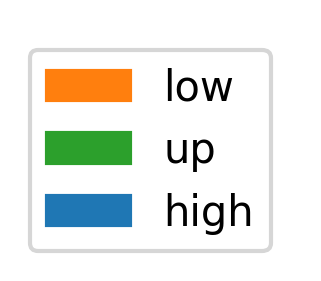

In [51]:
fig, ax = plt.subplots(1, 1, figsize=(1, 1), dpi=300)
ax.axis('off')
ax.legend(handles=[mpatches.Patch(color=colors[t], label=t) for t in ['low', 'up', 'high']])
fig.tight_layout()

/tmp/ipykernel_2658653/3625714584.py:5: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  sns.heatmap(classes.fillna('none').applymap(lambda s : mapping[s]), cmap=cmap, cbar=False,


<Axes: xlabel='threshold', ylabel='patient'>

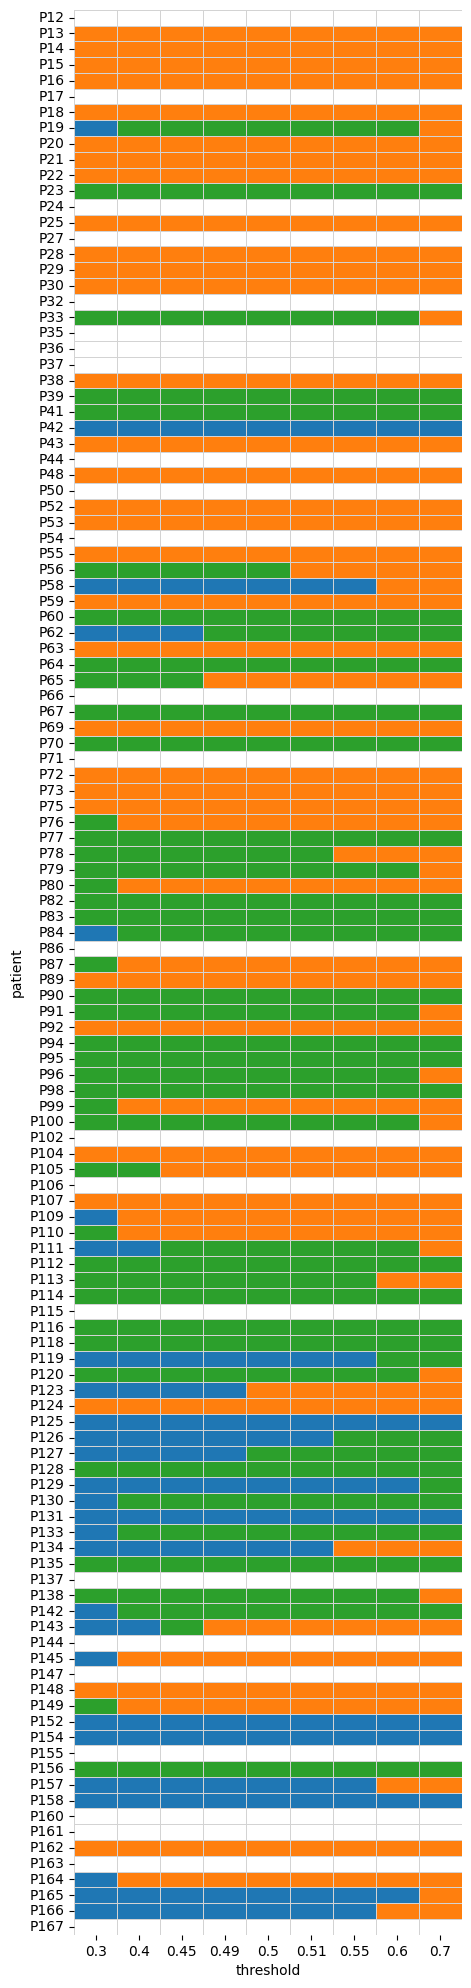

In [52]:
mapping = {'none' : np.nan, 'low' : 0, 'up' : 1, 'high' : 2}
cmap = LinearSegmentedColormap.from_list('Custom', [colors['low'], colors['up'], colors['high']], 3)

fig, ax = plt.subplots(1, 1, figsize=(5, 25))
sns.heatmap(classes.fillna('none').applymap(lambda s : mapping[s]), cmap=cmap, cbar=False,
            linewidths=.5, linecolor='lightgray')

### Fig. S5q


 ************************************************** threshold = 0.3 ************************************************** 

CensoredData(28 values: 5 not censored, 23 right-censored)
CensoredData(39 values: 3 not censored, 36 right-censored)
CensoredData(27 values: 1 not censored, 26 right-censored)


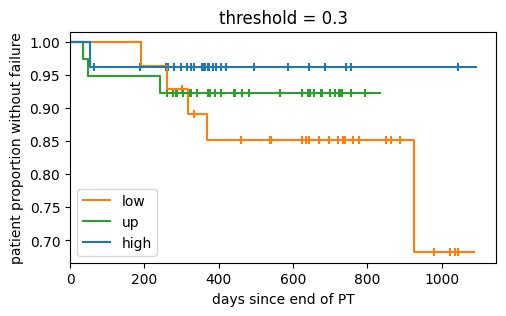

p-value for log-rank test with alternative low worse than high: 0.11730
p-value for log-rank test with alternative up worse than high: 0.25766
p-value for log-rank test with alternative low worse than up: 0.23369

 ************************************************** threshold = 0.4 ************************************************** 

CensoredData(37 values: 7 not censored, 30 right-censored)
CensoredData(38 values: 1 not censored, 37 right-censored)
CensoredData(19 values: 1 not censored, 18 right-censored)


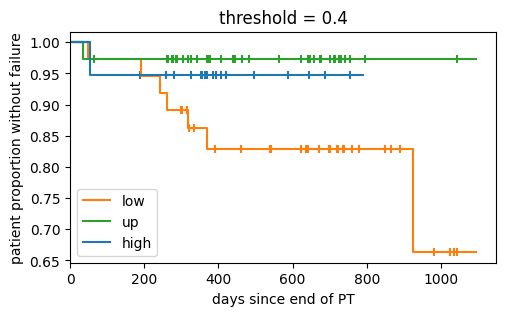

p-value for log-rank test with alternative low worse than high: 0.15035
p-value for log-rank test with alternative up worse than high: 0.68793
p-value for log-rank test with alternative low worse than up: 0.02531

 ************************************************** threshold = 0.45 ************************************************** 



CensoredData(38 values: 7 not censored, 31 right-censored)
CensoredData(39 values: 1 not censored, 38 right-censored)
CensoredData(17 values: 1 not censored, 16 right-censored)


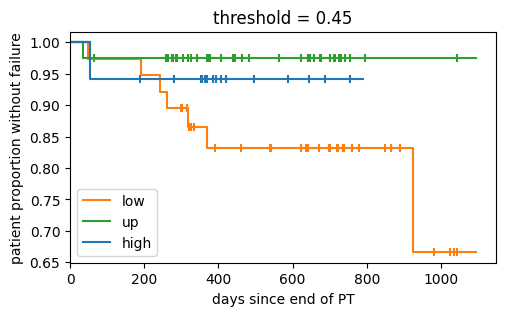

p-value for log-rank test with alternative low worse than high: 0.17934
p-value for log-rank test with alternative up worse than high: 0.72380
p-value for log-rank test with alternative low worse than up: 0.02600

 ************************************************** threshold = 0.49 ************************************************** 

CensoredData(40 values: 7 not censored, 33 right-censored)
CensoredData(38 values: 1 not censored, 37 right-censored)
CensoredData(16 values: 1 not censored, 15 right-censored)


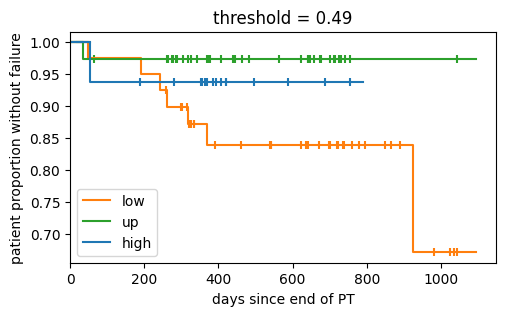

p-value for log-rank test with alternative low worse than high: 0.21170
p-value for log-rank test with alternative up worse than high: 0.73256
p-value for log-rank test with alternative low worse than up: 0.03084

 ************************************************** threshold = 0.5 ************************************************** 

CensoredData(41 values: 7 not censored, 34 right-censored)
CensoredData(39 values: 1 not censored, 38 right-censored)
CensoredData(14 values: 1 not censored, 13 right-censored)


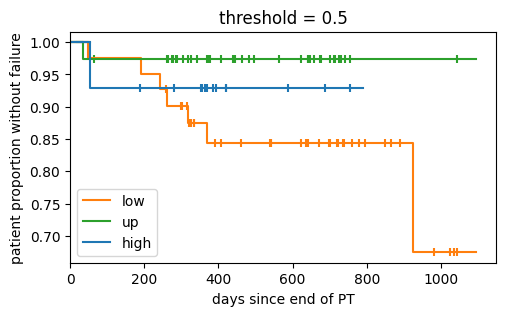

p-value for log-rank test with alternative low worse than high: 0.26929
p-value for log-rank test with alternative up worse than high: 0.77220
p-value for log-rank test with alternative low worse than up: 0.03070

 ************************************************** threshold = 0.51 ************************************************** 



CensoredData(42 values: 7 not censored, 35 right-censored)
CensoredData(38 values: 1 not censored, 37 right-censored)
CensoredData(14 values: 1 not censored, 13 right-censored)


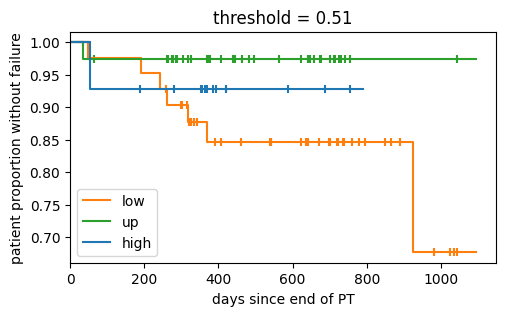

p-value for log-rank test with alternative low worse than high: 0.27654
p-value for log-rank test with alternative up worse than high: 0.76582
p-value for log-rank test with alternative low worse than up: 0.03488

 ************************************************** threshold = 0.55 ************************************************** 



CensoredData(44 values: 7 not censored, 37 right-censored)
CensoredData(38 values: 1 not censored, 37 right-censored)
CensoredData(12 values: 1 not censored, 11 right-censored)


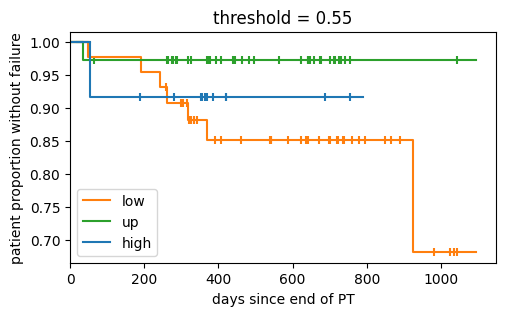

p-value for log-rank test with alternative low worse than high: 0.35596
p-value for log-rank test with alternative up worse than high: 0.80231
p-value for log-rank test with alternative low worse than up: 0.03814

 ************************************************** threshold = 0.6 ************************************************** 

CensoredData(48 values: 7 not censored, 41 right-censored)
CensoredData(38 values: 1 not censored, 37 right-censored)
CensoredData(8 values: 1 not censored, 7 right-censored)


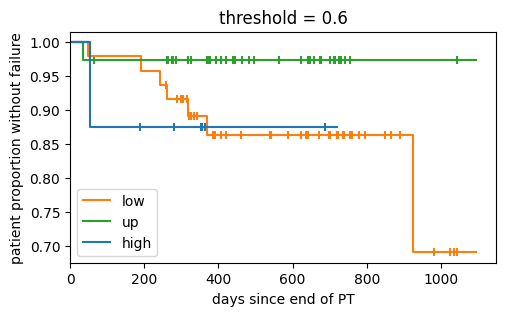

p-value for log-rank test with alternative low worse than high: 0.58810
p-value for log-rank test with alternative up worse than high: 0.88575
p-value for log-rank test with alternative low worse than up: 0.04681

 ************************************************** threshold = 0.7 ************************************************** 



CensoredData(58 values: 8 not censored, 50 right-censored)
CensoredData(30 values: 0 not censored, 30 right-censored)
CensoredData(6 values: 1 not censored, 5 right-censored)


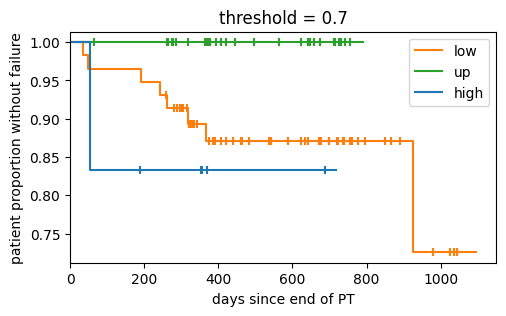

p-value for log-rank test with alternative low worse than high: 0.69313
p-value for log-rank test with alternative up worse than high: 0.98733
p-value for log-rank test with alternative low worse than up: 0.02686


In [53]:
for t in [0.3, 0.4, 0.45, 0.49, 0.5, 0.51, 0.55, 0.6, 0.7]:
    print('\n', 50*'*', f'threshold = {t}', 50*'*', '\n',)
    make_failure_plot(add_meta(classes[[t]].rename(columns={t : 'trajectory'})), title=f'threshold = {t}')

## Fig. 5d robustness

Leave-one-patient-out checks that the trajectory–outcome association in Fig. 5d is
not driven by individual patients (reviewer response). Reuses `patient_dates` and
`colors` from the Fig. 5d section above.

In [54]:
from matplotlib.lines import Line2D

GROUPS = ['low', 'up', 'high']


def make_censored(sub):
    right = sub.loc[sub['days to first failure'] == np.inf, 'days to last follow-up'].dropna().values
    unc = sub.loc[sub['days to first failure'] != np.inf, 'days to first failure'].dropna().values
    return stats.CensoredData(uncensored=unc, right=right)


def logrank_p(df, g_x, g_y):
    return stats.logrank(x=make_censored(df[df['trajectory'] == g_x]),
                         y=make_censored(df[df['trajectory'] == g_y]),
                         alternative='greater').pvalue

### Fig. S5r

Failure-free survival curves recomputed with each single failure patient removed
(thin lines) behind the full-cohort curves (thick): the `high` vs `low`/`up`
ordering is preserved under removal of any one event.

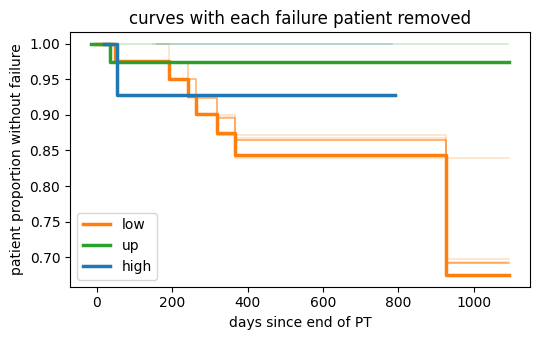

In [55]:
event_patients = patient_dates.loc[patient_dates['days to first failure'] != np.inf, 'patient']

fig, ax = plt.subplots(figsize=(5.5, 3.5))
# thin curves, each with one failure patient removed
for pid in event_patients:
    d = patient_dates[patient_dates['patient'] != pid]
    for g in GROUPS:
        sub = d[d['trajectory'] == g]
        if len(sub) == 0:
            continue
        stats.ecdf(make_censored(sub)).sf.plot(ax, color=colors[g], alpha=0.25, lw=1.1)
# thick full-cohort curves on top
for g in GROUPS:
    stats.ecdf(make_censored(patient_dates[patient_dates['trajectory'] == g])).sf.plot(
        ax, color=colors[g], lw=2.5, label=g)
ax.set_xlabel('days since end of PT')
ax.set_ylabel('patient proportion without failure')
ax.set_title('curves with each failure patient removed')
handles, labels = ax.get_legend_handles_labels()
seen = dict(zip(labels, handles))
ax.legend([seen[g] for g in GROUPS], GROUPS)
fig.tight_layout()
plt.show()

### Fig. S5s

Leave-one-patient-out for the reported `low` vs `up` log-rank test: p-value when
each patient is removed, split by whether the dropped patient had a failure and
colored by trajectory class. Only removing a `low` failure patient moves the
p-value appreciably, and no single removal changes the conclusion dramatically.

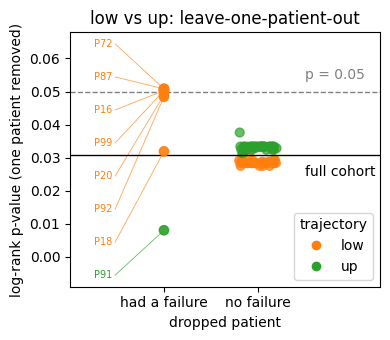

In [56]:
lu = patient_dates[patient_dates['trajectory'].isin(['low', 'up'])].copy()
lu['p'] = [logrank_p(patient_dates[patient_dates['patient'] != pid], 'low', 'up') for pid in lu['patient']]
lu['event patient'] = lu['days to first failure'] != np.inf
full_p_lu = logrank_p(patient_dates, 'low', 'up')
nf = lu[~lu['event patient']]
fail = lu[lu['event patient']].sort_values('p').reset_index(drop=True)

fig, ax = plt.subplots(figsize=(4, 3.5))  # same height as Fig. S5r for side-by-side layout
lab_size = ax.yaxis.label.get_fontsize()  # match 'full cohort'/'p ='/legend to the axis-label size
# failure dots pinned at x=0 (no jitter, so leader lines land exactly on them), colored by trajectory
ax.scatter(np.zeros(len(fail)), fail['p'], c=fail['trajectory'].map(colors), s=45, alpha=0.9, zorder=3)
# no-failure dots jittered around x=1
rng = np.random.default_rng(0)
ax.scatter(1 + (rng.random(len(nf)) - 0.5) * 0.4, nf['p'], c=nf['trajectory'].map(colors), s=40, alpha=0.7)

# spread the failure-patient labels vertically on the left, connected by faint leader lines
lo, hi = fail['p'].min(), fail['p'].max()
span = max(hi - lo, 0.07)          # guarantee enough room to separate labels
center = (lo + hi) / 2
lab_ys = np.linspace(center - span / 2, center + span / 2, len(fail)) if len(fail) > 1 else [center]
xlab = -0.55
for (_, r), ly in zip(fail.iterrows(), lab_ys):
    ax.plot([0, xlab + 0.03], [r['p'], ly], color=colors[r['trajectory']], lw=0.6, alpha=0.7, zorder=1)
    ax.annotate(r['patient'], (xlab, ly), va='center', ha='right', fontsize=7, color=colors[r['trajectory']])

ax.axhline(full_p_lu, color='black', lw=1)
ax.axhline(0.05, ls='--', color='gray', lw=1)
# the two lines are only ~0.01 apart: nudge full cohort below its line, p=0.05 above its line
ax.text(1.5, full_p_lu - 0.003, 'full cohort', va='top', ha='left', fontsize=lab_size, color='black')
ax.text(1.5, 0.05 + 0.003, 'p = 0.05', va='bottom', ha='left', fontsize=lab_size, color='gray')
ax.set_xticks([0, 1])
ax.set_xticklabels(['had a failure', 'no failure'])
ax.set_xlim(-1.0, 2.3)
ax.set_ylabel('log-rank p-value (one patient removed)')
ax.set_xlabel('dropped patient')
ax.set_title('low vs up: leave-one-patient-out')
present = [g for g in GROUPS if g in set(lu['trajectory'])]
ax.legend(handles=[Line2D([0], [0], marker='o', lw=0, color=colors[g], label=g) for g in present],
          title='trajectory', loc='lower right', fontsize=lab_size, title_fontsize=lab_size)
fig.tight_layout()
plt.show()

### Fig. S5t

Fig. 5d with the failure patients labeled. P37 and P66 also failed but have no trajectory class.

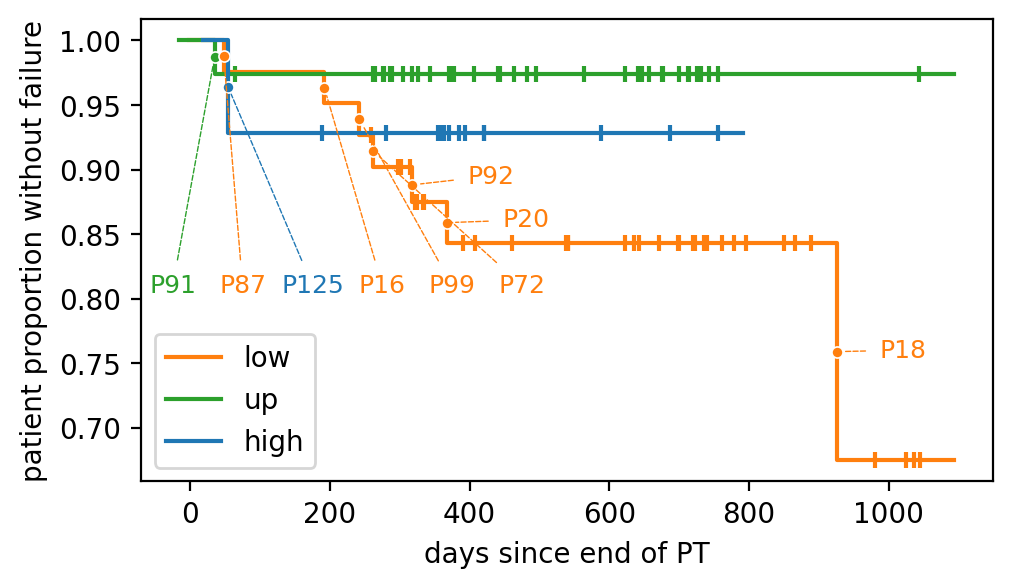

In [57]:
label_pos = {'P91' : (-25, 0.81), 'P87' : (75, 0.81), 'P125' : (175, 0.81), 'P16' : (275, 0.81),
             'P99' : (375, 0.81), 'P72' : (475, 0.81), 'P92' : (430, 0.895), 'P20' : (480, 0.861),
             'P18' : (1020, 0.76)}
ecdfs = {'low' : ecdf_low, 'up' : ecdf_up, 'high' : ecdf_high}
rights = {'low' : low_right, 'up' : up_right, 'high' : high_right}

fig, ax = plt.subplots(figsize=(5.5, 3), dpi=200)
for g in ['low', 'up', 'high']:
    ecdfs[g].sf.plot(ax, label=g, color=colors[g])
    ax.scatter(rights[g], ecdfs[g].sf.evaluate(rights[g]), marker='|', color=colors[g])
for p, pos in label_pos.items():
    row = patient_dates[patient_dates['patient'] == p].iloc[0]
    g, d = row['trajectory'], row['days to first failure']
    y = (ecdfs[g].sf.evaluate(d - 0.5) + ecdfs[g].sf.evaluate(d)) / 2
    ax.plot(d, y, marker='o', ms=4, color=colors[g], mec='white', mew=0.6, zorder=5)
    ax.annotate(p, (d, y), xytext=pos, textcoords='data', ha='center', va='center',
                fontsize=9, color=colors[g], zorder=6,
                arrowprops=dict(arrowstyle='-', linestyle='--', color=colors[g], lw=0.5, shrinkA=3, shrinkB=3))
ax.set_xlabel('days since end of PT')
ax.set_ylabel('patient proportion without failure')
plt.legend()
plt.show()